In [1]:
import os
import pandas as pd
from matplotlib import pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import ast
import numpy as np
plt.style.use('tableau-colorblind10')
from matplotlib.lines import Line2D

colors_blind=['#006BA4', '#FF800E', '#ABABAB', '#595959',
                 '#5F9ED1', '#C85200', '#898989', '#A2C8EC', '#FFBC79', '#CFCFCF']
from Plotting_base_code import plotting_pytorch as plotting
from CNN_code import cnn_create


/home/simrank/.local/lib/python3.8/site-packages/pandas/core/computation/expressions.py:20: UserWarning: Pandas requires version '2.7.3' or newer of 'numexpr' (version '2.7.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


In [6]:
class plot:
    def __init__(self):
        self.x_fontsize_label=25
        self.y_fontsize_label=25
        self.x_fontsize=15
        self.y_fontsize=15
        self.t_fontsize=20
        self.size_prop=15

        self.row=7
        self.col=5


        self.figure_size=(20,25)
        # figure_size=(10,12)
        self.rotation=30
        self.w_space=0.1
        self.h_space=0.1
        self.markersize=5
        self.title_font=15
        self.label_text='% corruption degree'
        self.x_label='Epoch'
        self.pad_value=10
        self.corruption=[0.0,0.2,0.4,0.6,0.8,1.0]
        
 
    def divide_function(self,list_value,int_value):
        newList = []
        for x in list_value:
            newList.append(x/int_value)
        return newList
    def print_x_axis(self,values_xaxis):
        x_labels = list(map(int, values_xaxis))  
        max_val = max(x_labels)

        # Decide step size adaptively
        if max_val <= 40:
            tick_labels = list(range(0, max_val + 1, 10))
        elif max_val >= 300:
            tick_labels = list(range(0, max_val + 1, 80))
        else:
            tick_labels = list(range(0, max_val + 1, 40))

        # Find closest indices in x_labels for each desired tick
        tick_indices = [min(range(len(x_labels)), key=lambda i: abs(x_labels[i] - val))
                        for val in tick_labels if val <= max_val]

        return tick_labels, tick_indices, x_labels


        
    def accuracy_model(self,type_acc,data_name,corrupt,tiny=False):
        if data_name=='Testing':
            data='Test_accuracy'
        run=[]
        for run_type in range(1,4,1):
            if tiny:
                num_epoch,min_epoch=plotting.final_epoch_tiny(corrupt,run_type)
                x_acc=[i for i in range(-1,min_epoch,1)]+[num_epoch]
                x_acc[0]=0
                if corrupt==0.8 or corrupt==1.0:
                    models_load=cnn_create.select_model(x_acc,tiny)
                else:
                    models_load=cnn_create.select_model(x_acc,tiny)+[x_acc[-1]-1]        
                run.append(self.divide_function(pd.read_csv(f'{type_acc}/Run_{run_type}.csv')
                                           .sort_values(by='epoch')[data]
                                           [models_load].tolist(),100))
            else:
                
                num_epoch=(pd.read_csv(f'{type_acc}/Run_{run_type}.csv')
                           .sort_values(by='epoch')['epoch']).tolist()[-1]
                x_acc=[i for i in range(-1,num_epoch,1)]
                x_acc[0]=0
                run.append(self.divide_function(pd.read_csv(f'{type_acc}/Run_{run_type}.csv')
                                           .sort_values(by='epoch')[data]
                                           [cnn_create.select_model(x_acc,tiny)].tolist(),100))
   
        return run
    
    def label_names_fn(self,network,data_name):
        if data_name=='Testing':
            name_title='Test'
        if data_name=='Corrupted Training':
            name_title='data_name'
        if network =='MLP':
            labels_names=[f'Model {name_title} Accuracy','FC1 (128)',
                      'FC2 (512)','FC3 (2048)','FC4 (2048)']    #'Input',    

        if network =='CNN': 
            labels_names=[f'Model {name_title} Accuracy','Flat (576/1024)',
                          'FC1 (250)','FC2 (250)','FC3 (250)'] #'Input',
            
        if network =='AlexNet':
            labels_names= [f'Model {name_title} Accuracy','Flat (256)','FC1 (4096)','FC2 (4096)']  
        if network =='ResNet18':
            labels_names= [f'Model {name_title} Accuracy','L0','L1','L2','L3','L4','Avg_pool']  #
        return labels_names
    def layer_info(self,network):
        if network =='MLP':
            labels_names=[f'Model test accuracy','Input',
                          'FC1 (128)','FC2 (512)','FC3 (2048)','FC4 (2048)']        
            data_layer_name=['input','fc1','fc2','fc3','fc4']                

        elif network =='CNN': 
            labels_names=[f'Model test accuracy','Input',
                      'Flat (576/1024)',
                      'FC1 (250)','FC2 (250)','FC3 (250)']        

            data_layer_name=['input','flattern','fc1','fc2','fc3']
        elif network =='AlexNet':     
            labels_names=[f'Model test accuracy','Flat (256)',
                          'FC1 (4096)','FC2 (4096)']        
            data_layer_name=['flattern','fc1','fc2']

        elif network =='ResNet18':       
            labels_names = ['Model test accuracy','L0','L1',
                            'L2','L3','L4','Avg_pool'] 
            data_layer_name = ['l0','l1','l2','l3','l4','bf_last']
        return labels_names,data_layer_name
    
    def folder_results(self,resfoldername, fold_type):
        
        os.makedirs(f'{resfoldername}',exist_ok=True)
        os.makedirs(f'{resfoldername}/{fold_type}',exist_ok=True)
        os.makedirs(f'{resfoldername}/{fold_type}/pdf',exist_ok=True)
        os.makedirs(f'{resfoldername}/{fold_type}/png',exist_ok=True)

        result1=f'{resfoldername}/{fold_type}/pdf'
        result2=f'{resfoldername}/{fold_type}/png'
        
        return [result1 , result2]
           
    
   
    
    def accuracy_model_all(self,type_acc,data_name,corrupt,tiny=False):
        run=[]
        if data_name=='Corrupted Training':
            data='Train_accuracy'

        if data_name=='Testing':
            data='Test_accuracy'

        for run_type in ['Run_1','Run_2','Run_3']:

            num_epoch=(pd.read_csv(f'{type_acc}/{run_type}.csv')
                       .sort_values(by='epoch')['epoch']).tolist()[-1]
            x_acc=[i for i in range(-1,num_epoch,1)]
            x_acc[0]=0

            if data_name=='Original Training':
                if corrupt ==0.0:
                    data='Train_accuracy'
                    run.append(self.divide_function(pd.read_csv(f'{type_acc}/{run_type}.csv')
                                               .sort_values(by='epoch')[data]
                                               [cnn_create.select_model(x_acc,tiny)].tolist(),100))
                else:
                    data='Train_accuracy_org'
                    run.append(self.divide_function(pd.read_csv(f'{type_acc}/{run_type}_org.csv')
                                               .sort_values(by='epoch')[data]
                                               [cnn_create.select_model(x_acc,tiny)].tolist(),100))

            else:
                run.append(self.divide_function(pd.read_csv(f'{type_acc}/{run_type}.csv')
                                               .sort_values(by='epoch')[data]
                                               [cnn_create.select_model(x_acc,tiny)].tolist(),100))

        return run
    
    def main_appendix(self,subspace_type,data_name,n):
        networks=['MLP','MLP','CNN','CNN','CNN']
        data_types=['MNIST','CIFAR10','MNIST','FashionMNIST','CIFAR10']
        labels_names_total=[f'Model test accuracy',
                    'MLP-FC1 (128)/ CNN-Flat (576/1024)/ AlexNet-Flat (256)/ ResNet-18-L0',
                    'MLP-FC2 (512)/ CNN-FC1 (250)/ AlexNet-FC1 (4096)/ ResNet-18-L1',
                    'MLP-FC3 (2048)/ CNN-FC2 (250)/ AlexNet-FC2 (4096)/ ResNet-18-L2',
                    'MLP-FC4 (2048)/ CNN-FC3 (250)/ ResNet-18-L3','ResNet-18-L4',
                            'ResNet-18-Avg_pool']  
    
  
        file_final_name=f'ACCURACY_{subspace_type}_{data_name}_{n}_all'

        return networks,data_types,labels_names_total,file_final_name
    def baseline_path(self,ds,network,corrupt,run):
        path_lg=f'../BASELINES/results/logistic_regression/{ds}_{network}/results_{corrupt}/Run_{run}'
        return path_lg
    
    
    def accuracy_model_tiny(self,type_acc,data_name,path_x_values,corrupt,tiny=False):

        run=[]
        if data_name=='Corrupted Training':
            data='Train_accuracy'
        if data_name=='Testing':
            data='Test_accuracy'


        len_x_run=[]
        last_values_xaxis=[]

        for run_type in range(1,4):  
            num_epoch,min_epoch=self.final_epoch_tiny(corrupt,run_type)
            x_acc=[i for i in range(-1,min_epoch,1)]+[num_epoch]
            x_acc[0]=0
            if corrupt==0.8 or corrupt==1.0:
                models_load=cnn_create.select_model(x_acc,tiny)
            else:
                models_load=cnn_create.select_model(x_acc,tiny)+[x_acc[-1]-1]        
            run.append(self.divide_function(pd.read_csv(f'{type_acc}/Run_{run_type}.csv')
                                       .sort_values(by='epoch')[data]
                                       [models_load].tolist(),100))

            path_model_num=f'{path_x_values}/angle_results/Run_{run_type}/'
            len_x_run.append(len(os.listdir(path_model_num)))
            if tiny:
                last_values_xaxis.append(sorted(os.listdir(path_model_num),key=int)[-1])
        len_x=min(len_x_run)
        x=[i for i in range(len_x)]
        ind_len=len_x_run.index(len_x)                     
        path_model=f'{path_x_values}/angle_results/Run_{ind_len+1}/'      
        if tiny:
            values_xaxis=sorted(os.listdir(path_model),key=int)[:-1]
            values_xaxis=values_xaxis+last_values_xaxis
        else:
            values_xaxis=sorted(os.listdir(path_model),key=int)

        return run,values_xaxis,x
    
    
    def final_epoch_tiny(self,corrupt,run):
        if corrupt==0.0:
            epoch=[175,178,167]
        if corrupt==0.2:
            epoch=[184,194,193]
        if corrupt==0.4:
            epoch=[263,240,272]
        if corrupt==0.6:
            epoch=[449,426,428]
        if corrupt==0.8 or corrupt==1.0:
            epoch=[499,499,499]

        return epoch[run-1]+1,min(epoch)+1

    def plotting_log_reg(self,resfoldername,corruptions):

        subspace_type='corrupt'
        folder_name='angle_results'
        fold_type='logistic_reg'
        result1,result2=self.folder_results(resfoldername,fold_type)
        data_name='Testing'
        name_title='Test'

        if corruptions:
            self.corruption=[0.2,0.4,0.6,0.8]
            name_2='2_8'
            self.figure_size=(20,20)
            self.col=4
        else:
            self.corruption=[0.0]#1.0
            name_2='0' 
            self.figure_size=(20,20)
            
            plo.col=1
        plo.row=7
        y_label=f'Logistic Regression Probe {name_title} Accuracy'

        n=1
        mavc=True
        train=True
        networks,data_types,labels_names_total,file_final_name=self.main_appendix(subspace_type,data_name,n)
        custom_colors=[colors_blind[0],
                    colors_blind[2],colors_blind[3],
                       colors_blind[4],colors_blind[5],
                    colors_blind[6],colors_blind[8]]
        line_styles = [':','-','-','-','-','-','-','-'] 

        fig = plt.figure(figsize=plo.figure_size)
        plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=self.w_space, hspace=self.h_space)

        count=1
        for network,data_type in zip(networks,data_types):
            for corrupt in self.corruption:


                data_layer_name=plotting.layer_name_acc(network)

                labels_names=self.label_names_fn(network,data_name)    

                type_cnn,type_acc=plotting.path(network,data_type,corrupt,n,mavc,train)

                fig.add_subplot(self.row, self.col,count)

                run_acc=self.accuracy_model(type_acc,data_name,corrupt)
                values_xaxis,x=plotting.epoch_all_accuracy(type_cnn)
                tick_labels,tick_indices,x_labels=self.print_x_axis(values_xaxis)            

                max_value,min_value,avg_value=plotting.fun_1(run_acc)
                len_avg=len(avg_value)

                max_value[0]=0.10
                min_value[0]=0.10
                avg_value[0]=0.10
                plt.plot(x_labels[:len_avg],avg_value,':',markersize=self.markersize,
                         label=labels_names[0],color=colors_blind[0])
                color_count=2
                data_layer_name=data_layer_name[1:]
                labels_names=labels_names[1:]
                for layer,labels_name in zip(data_layer_name,labels_names):
                    run_layer=[]
                    run=1
        #             for run in range(1,4):
                    run_value=[]
                    for model_number in values_xaxis:
                        path_lg=self.baseline_path(data_type,network,corrupt,run)

                        run_value.append(pd.read_csv(f'{path_lg}/{model_number}/layer_{layer}_acc_overall_test.csv')['acc_overall'][0]/100)

                    run_layer.append(run_value)
                    plt.plot(x_labels[:len_avg],run_layer[0],markersize=self.markersize,
                             label=labels_name,color=colors_blind[color_count])

                    color_count=color_count+1
                plt.yticks(fontsize= self.y_fontsize)
                plt.xticks([x_labels[i] for i in tick_indices])

                if (count - 1) % self.col == 0:  
                    plt.ylabel(f'{network}-{plotting.get_datasetname(data_type)}',
                               fontsize=self.title_font)
                if count<= self.col:
                    plt.title(f'{plotting.get_corrupt(corrupt)}{self.label_text}',
                              fontsize=self.t_fontsize,pad=self.pad_value)

                plt.ylim(-0.01,1.01)
                count=count+1
        network='AlexNet'
        data_type='TinyImageNet'            
        for corrupt in self.corruption:

            labels_names,data_layer_name=self.layer_info(network)
            type_cnn,type_acc=plotting.path(network,data_type,corrupt,n,mavc,train)

            fig.add_subplot(self.row,self.col,count)
            run_acc,values_xaxis,x=self.accuracy_model_tiny(type_acc,data_name,
                                                  type_cnn,corrupt,tiny=True)

            tick_labels,tick_indices,x_labels=self.print_x_axis(values_xaxis)            

            max_value,min_value,avg_value=plotting.fun_1(run_acc)
            len_avg=len(avg_value)

            max_value[0]=0.005
            min_value[0]=0.005
            avg_value[0]=0.005
            plt.plot(x_labels[:len_avg-1],avg_value[:-1],':',markersize=self.markersize,
                     label=labels_names[0], color=colors_blind[0])

            color_count=2            

            for layer,labels_name in zip(data_layer_name,labels_names[1:]):
                run_layer=[]
                run=1
        #         for run in range(1,4):
                run_value=[]
                for model_number in values_xaxis[:-3]:
                    path_lg=self.baseline_path(data_type,network,corrupt,run)

                    run_value.append(pd.read_csv(f'{path_lg}/{model_number}/layer_{layer}_acc_overall_test.csv')['acc_overall'][0]/100)

                run_layer.append(run_value)
                plt.plot(x_labels[:len_avg-1],run_layer[0],markersize=self.markersize,
                         label=labels_name,color=colors_blind[color_count])
                color_count=color_count+1
            plt.yticks(fontsize=self.y_fontsize)
            plt.xticks([x_labels[i] for i in tick_indices])

            if (count - 1) % self.col == 0:  
                plt.ylabel(f'{network}-{plotting.get_datasetname(data_type)}',
                           fontsize=self.title_font)
            if count<= self.col:
                plt.title(f'{plotting.get_corrupt(corrupt)}{self.label_text}',
                          fontsize=self.t_fontsize,pad=plo.pad_value)


            count=count+1

        network='ResNet18'
        data_type='CIFAR10' 
        for corrupt in self.corruption:
            if corrupt==1.0:
                continue
            data_layer_name=plotting.layer_name_acc(network)

            labels_names=self.label_names_fn(network,data_name)    

            type_cnn,type_acc=plotting.path(network,data_type,corrupt,n,mavc,train)

            fig.add_subplot(self.row, self.col,count)

            run_acc=self.accuracy_model(type_acc,data_name,corrupt)
            values_xaxis,x=plotting.epoch_all_accuracy(type_cnn)
            tick_labels,tick_indices,x_labels=self.print_x_axis(values_xaxis)            

            max_value,min_value,avg_value=plotting.fun_1(run_acc)
            len_avg=len(avg_value)

            max_value[0]=0.10
            min_value[0]=0.10
            avg_value[0]=0.10
            plt.plot(x_labels[:len_avg],avg_value,':',markersize=self.markersize,
                     label=labels_names[0],color=colors_blind[0])
        #     plt.fill_between(x_labels[:len_avg],min_value, max_value, alpha=.2,label='_nolegend_')
            color_count=2
            for layer,labels_name in zip(data_layer_name,labels_names[1:]):

                run_layer=[]
                run=1
        #         for run in range(1,4):
                run_value=[]
                for model_number in values_xaxis:
                    path_lg=self.baseline_path(data_type,network,corrupt,run)
                    run_value.append(pd.read_csv(f'{path_lg}/{model_number}/layer_{layer}_acc_overall_test.csv')['acc_overall'][0]/100)
                run_layer.append(run_value)
                plt.plot(x_labels[:len_avg],run_layer[0],markersize=self.markersize,
                         label=labels_name,color=colors_blind[color_count])
                
                if color_count==6:
                    color_count=color_count+2
                else:           
                    color_count=color_count+1

            plt.yticks(fontsize= self.y_fontsize)
            plt.xticks([x_labels[i] for i in tick_indices])


            if (count - 1) % self.col == 0:  
                plt.ylabel(f'ResNet-18-{plotting.get_datasetname(data_type)}',
                           fontsize=self.title_font)
            if count<= self.col:
                plt.title(f'{plotting.get_corrupt(corrupt)}{self.label_text}',
                          fontsize=self.t_fontsize,pad=plo.pad_value)

            plt.ylim(-0.01,1.01)
            
            count=count+1


        handles = [Line2D([0], [0], color=color, lw=2,linestyle=style) 
                   for color, style in zip(custom_colors, line_styles)
                  ]
        fig.legend(handles=handles,labels=labels_names_total, loc='upper center', 
           ncol=2,prop = { "size": self.size_prop})
        plt.tight_layout(rect=[0.05, 0.05, 1, 0.93])

        fig.text(0.5, 0.03, self.x_label, ha='center',fontsize=self.x_fontsize_label)
        fig.text(0.04, 0.5, y_label, va='center', rotation='vertical',
                 fontsize=self.y_fontsize_label)

        plt.savefig(f'{result1}/{file_final_name}_{name_2}_logistic_reg.pdf',format="pdf", bbox_inches="tight")
        plt.savefig(f'{result2}/{file_final_name}_{name_2}_logistic_reg.png', dpi=400)


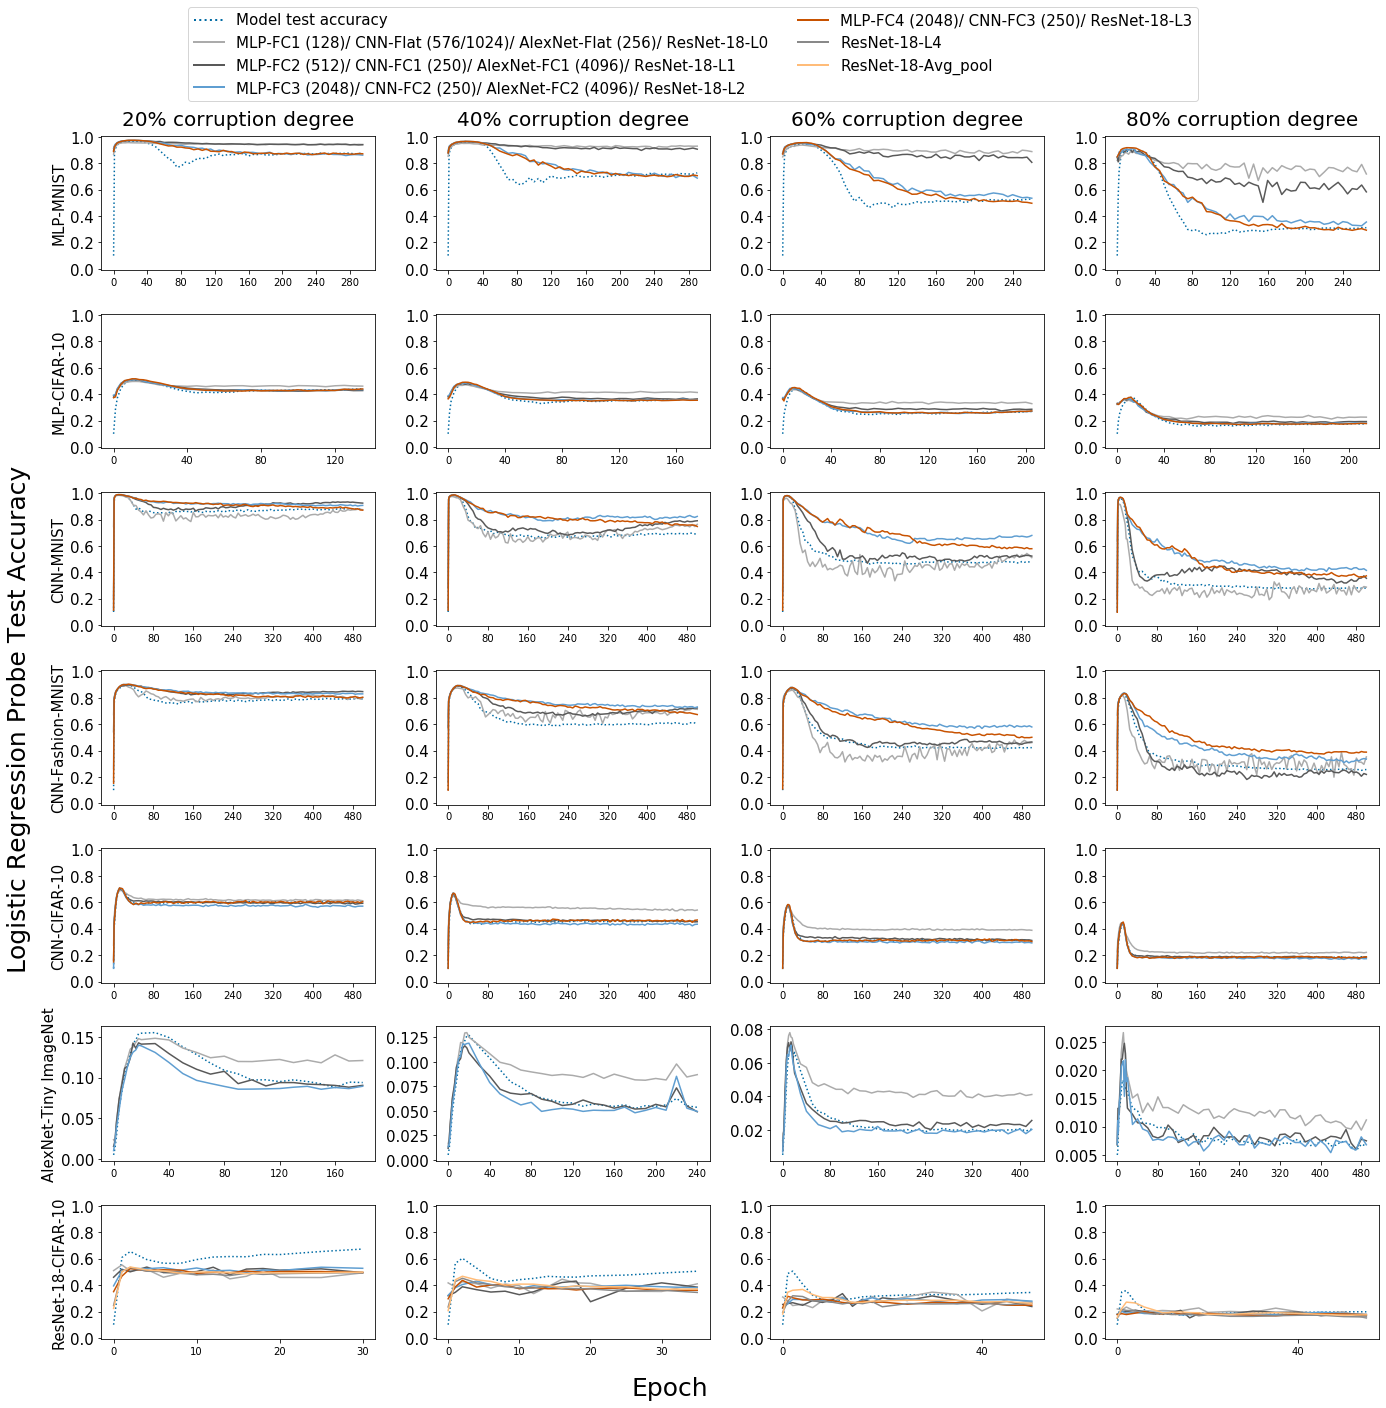

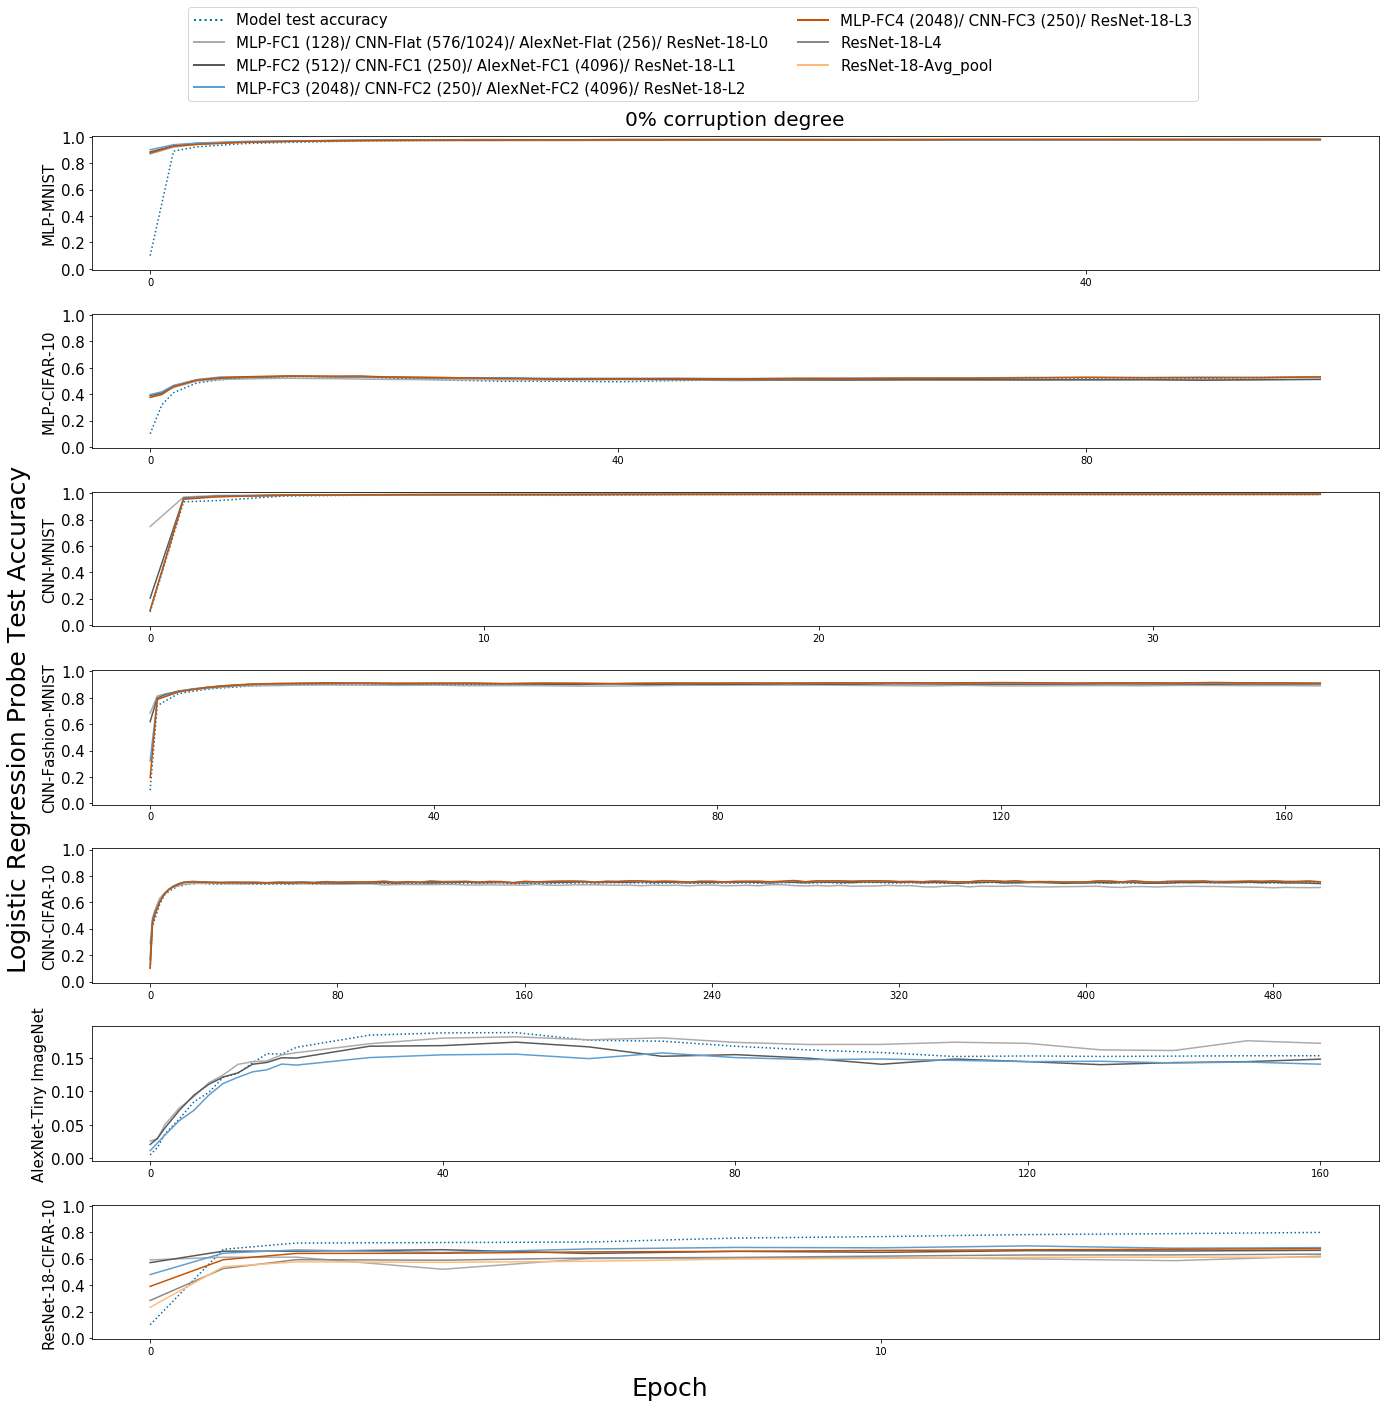

In [7]:
plo=plot()
resfoldername='TMLR_PAPER_PLOTS2'
plo.plotting_log_reg(resfoldername,corruptions=True)
plo.plotting_log_reg(resfoldername,corruptions=False)

# difference between MASC and Logistic regression

In [8]:
class plot_DIFF(plot):
    def subtract_list(self,list1,list2):
        result = []
        for i in range(len(list1)):
            result.append(list1[i] - list2[i])

        return result

    def read_file_name(self,data_name,type_cnn,folder_name,run,model_number,layer):
        if data_name == 'Testing' :
            file_name=f'{type_cnn}/{folder_name}/Run_{run}/{model_number}/layer_{layer}_acc_overall_test.csv'
        if data_name == 'Corrupted Training' :
            file_name=f'{type_cnn}/{folder_name}/Run_{run}/{model_number}/layer_{layer}_acc_overall_train.csv'
        if data_name == 'Original Training' :
            file_name=f'{type_cnn}/angle_results_exp2/Run_{run}/{model_number}/layer_{layer}_acc_overall_train.csv'
        return file_name

    def plot_diff_log_reg(self,resfoldername,masc,corruptions):
        train=True

        data_name='Testing'
        name_title='Test'
        subspace_type='corrupt'
        folder_name='angle_results'


        fold_type='logistic_reg'
        result1,result2=self.folder_results(resfoldername,fold_type)
        if masc:
            y_label=f'Difference in {name_title} Accuracy (MASC Acc. - Logistic regression Acc.)'
        else:
            y_label=f'Difference in {name_title} Accuracy (VeLPIC Acc. - Logistic regression Acc.)'


        if corruptions:
            self.corruption=[0.2,0.4,0.6,0.8]
            name_2='2_8'
            self.figure_size=(20,20)
            self.y_fontsize_label=23
            self.col=4
        else:
            self.corruption=[0.0]#1.0.
            name_2='0' 
            self.figure_size=(20,20)
            self.y_fontsize_label=20
            self.col=1
        self.row=7

        n='diff'
        networks,data_types,labels_names_total,file_final_name=self.main_appendix(subspace_type,data_name,n)
        custom_colors=[colors_blind[0],colors_blind[2],
                       colors_blind[3],colors_blind[4],colors_blind[5],
                        colors_blind[6],colors_blind[8]]
        line_styles = [':', '-', '-', '-', '-', '-', '-', '-'] 
        fig = plt.figure(figsize=plo.figure_size)
        plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=self.w_space, hspace=self.h_space)

        count=1

        for network,data_type in zip(networks,data_types):
            for corrupt in self.corruption:

                data_layer_name=plotting.layer_name_acc(network)

                labels_names=self.label_names_fn(network,data_name)    
                if masc==True:
                    mavc=False
                    n=0.99
                else:
                    mavc=True
                    n=1
                type_cnn,type_acc=plotting.path(network,data_type,corrupt,n,mavc,train)

                run_acc=self.accuracy_model(type_acc,data_name,corrupt)
                values_xaxis,x=plotting.epoch_all_accuracy(type_cnn)
                tick_labels,tick_indices,x_labels=self.print_x_axis(values_xaxis)            

                max_value,min_value,avg_value=plotting.fun_1(run_acc)
                len_avg=len(avg_value)

                max_value[0]=0.10
                min_value[0]=0.10
                avg_value[0]=0.10

                fig.add_subplot(self.row, self.col,count)


                plt.plot(x_labels[:len_avg],self.subtract_list(avg_value,avg_value),
                         ':',markersize=self.markersize,
                         label=labels_names[0],color=colors_blind[0])
                color_count=2
                data_layer_name=data_layer_name[1:]
                labels_names=labels_names[1:]
                for layer,labels_name in zip(data_layer_name,labels_names):
                    type_cnn,type_acc=plotting.path(network,data_type,corrupt,n,mavc,train)
                    run=1
                    run_value=[]
                    run_value_lr=[]

                    for model_number in values_xaxis:
                        run_value.append(pd.read_csv(f'{type_cnn}/{folder_name}/Run_{run}/{model_number}/layer_{layer}_acc_overall_test.csv')['acc_overall'][0])

                        path_lg=plo.baseline_path(data_type,network,corrupt,run)
                        run_value_lr.append(pd.read_csv(f'{path_lg}/{model_number}/layer_{layer}_acc_overall_test.csv')['acc_overall'][0]/100)

                    plt.plot(x_labels[:len_avg],self.subtract_list(run_value,run_value_lr),
                             markersize=self.markersize,
                             label=labels_name,color=colors_blind[color_count])

                    color_count=color_count+1
                plt.yticks(fontsize= self.y_fontsize)
                plt.xticks([x_labels[i] for i in tick_indices])


                if (count - 1) % self.col == 0:  
                    plt.ylabel(f'{network}-{plotting.get_datasetname(data_type)}',
                               fontsize=self.title_font)
                if count<= self.col:
                    plt.title(f'{plotting.get_corrupt(corrupt)}{self.label_text}',
                              fontsize=self.t_fontsize,pad=self.pad_value)

                count=count+1
        network='AlexNet'
        data_type='TinyImageNet'
        for corrupt in self.corruption:
            labels_names,data_layer_name=self.layer_info(network)
            if masc==True:
                mavc=False
                n=0.99
            else:
                mavc=True
                n=1

            type_cnn,type_acc=plotting.path(network,data_type,corrupt,n,mavc,train)
        #                 print(type_cnn)

            run_acc,values_xaxis,x=self.accuracy_model_tiny(type_acc,data_name,
                                                  type_cnn,corrupt,tiny=True)


            max_value,min_value,avg_value=plotting.fun_1(run_acc)
            len_avg=len(avg_value)

            max_value[0]=0.005
            min_value[0]=0.005
            avg_value[0]=0.005

            fig.add_subplot(self.row,self.col,count)

            tick_labels,tick_indices,x_labels=self.print_x_axis(values_xaxis)

            plt.plot(x_labels[:len_avg-1],self.subtract_list(avg_value[:-1],avg_value[:-1]),
                     ':',markersize=self.markersize,
                     label=labels_names[0], color=colors_blind[0])

            color_count=2            

            for layer,labels_name in zip(data_layer_name,labels_names[1:]):
                type_cnn,type_acc=plotting.path(network,data_type,corrupt,n,mavc,train)
                run=1
                run_value_lr=[]
                run_value=[]

                for model_number in values_xaxis[:-3]:
                    file_name_final=self.read_file_name(data_name,type_cnn,
                                                           folder_name,run,
                                                           model_number,layer)
                    run_value.append(pd.read_csv(file_name_final)['acc_overall'][0])

                    path_lg=self.baseline_path(data_type,network,corrupt,run)
                    run_value_lr.append(pd.read_csv(f'{path_lg}/{model_number}/layer_{layer}_acc_overall_test.csv')['acc_overall'][0]/100)
                                
                plt.plot(x_labels[:len_avg-1],self.subtract_list(run_value,run_value_lr),
                             markersize=self.markersize,
                             label=labels_name,color=colors_blind[color_count])                
                color_count=color_count+1
            plt.yticks(fontsize=self.y_fontsize)
            plt.xticks([x_labels[i] for i in tick_indices])

            if (count - 1) % self.col == 0:  
                plt.ylabel(f'{network}-{plotting.get_datasetname(data_type)}',
                           fontsize=self.title_font)
            if count<= self.col:
                plt.title(f'{plotting.get_value(corrupt)}{label_text}',
                          fontsize=self.t_fontsize,pad=self.pad_value)

            count=count+1

        network='ResNet18'
        data_type='CIFAR10' 
        for corrupt in self.corruption:
            if corrupt==1.0:
                continue
            data_layer_name=plotting.layer_name_acc(network)

            labels_names=self.label_names_fn(network,data_name)    
            if masc==True:
                mavc=False
                n=0.99
            else:
                mavc=True
                n=1
            type_cnn,type_acc=plotting.path(network,data_type,corrupt,n,mavc,train)

            run_acc=self.accuracy_model(type_acc,data_name,corrupt)
            values_xaxis,x=plotting.epoch_all_accuracy(type_cnn)
            tick_labels,tick_indices,x_labels=self.print_x_axis(values_xaxis)            

            max_value,min_value,avg_value=plotting.fun_1(run_acc)
            len_avg=len(avg_value)

            max_value[0]=0.10
            min_value[0]=0.10
            avg_value[0]=0.10

            fig.add_subplot(self.row, self.col,count)

            plt.plot(x_labels[:len_avg],self.subtract_list(avg_value,avg_value),
                     ':',markersize=self.markersize,
                     label=labels_names[0],color=colors_blind[0])
            color_count=2
            for layer,labels_name in zip(data_layer_name,labels_names[1:]):
                type_cnn,type_acc=plotting.path(network,data_type,corrupt,n,mavc,train)
                run=1
                run_value=[]
                run_value_lr=[]

                for model_number in values_xaxis:
                    run_value.append(pd.read_csv(f'{type_cnn}/{folder_name}/Run_{run}/{model_number}/layer_{layer}_acc_overall_test.csv')['acc_overall'][0])

                    path_lg=plo.baseline_path(data_type,network,corrupt,run)
                    run_value_lr.append(pd.read_csv(f'{path_lg}/{model_number}/layer_{layer}_acc_overall_test.csv')['acc_overall'][0]/100)

                plt.plot(x_labels[:len_avg],self.subtract_list(run_value,run_value_lr),
                         markersize=self.markersize,label=labels_name,color=colors_blind[color_count])
                if color_count==6:
                    color_count=color_count+2
                else:           
                    color_count=color_count+1
            plt.yticks(fontsize= self.y_fontsize)
            plt.xticks([x_labels[i] for i in tick_indices])

            if (count - 1) % self.col == 0:  
                plt.ylabel(f'ResNet-18-{plotting.get_datasetname(data_type)}',
                           fontsize=self.title_font)
            if count<= self.col:
                plt.title(f'{plotting.get_corrupt(corrupt)}{self.label_text}',
                          fontsize=self.t_fontsize,pad=self.pad_value)

            count=count+1
        handles = [Line2D([0], [0], color=color, lw=2,linestyle=style) 
                   for color, style in zip(custom_colors, line_styles)
                  ]
        fig.legend(handles=handles,labels=labels_names_total, loc='upper center', 
           ncol=2,prop = { "size": self.size_prop})
        plt.tight_layout(rect=[0.05, 0.05, 1, 0.93])

        fig.text(0.5, 0.03, self.x_label, ha='center',fontsize=self.x_fontsize_label)
        fig.text(0.03, 0.5, y_label, va='center', rotation='vertical',
                 fontsize=self.y_fontsize_label)
        if masc:
            plt.savefig(f'{result1}/{file_final_name}_{name_2}_masc_lg_diff.pdf',format="pdf", bbox_inches="tight")
            plt.savefig(f'{result2}/{file_final_name}_{name_2}_masc_lg_diff.png', dpi=400)          
        else:
            plt.savefig(f'{result1}/{file_final_name}_{name_2}_mavc_lg_diff.pdf',format="pdf", bbox_inches="tight")
            plt.savefig(f'{result2}/{file_final_name}_{name_2}_mavc_lg.png', dpi=400)          
    

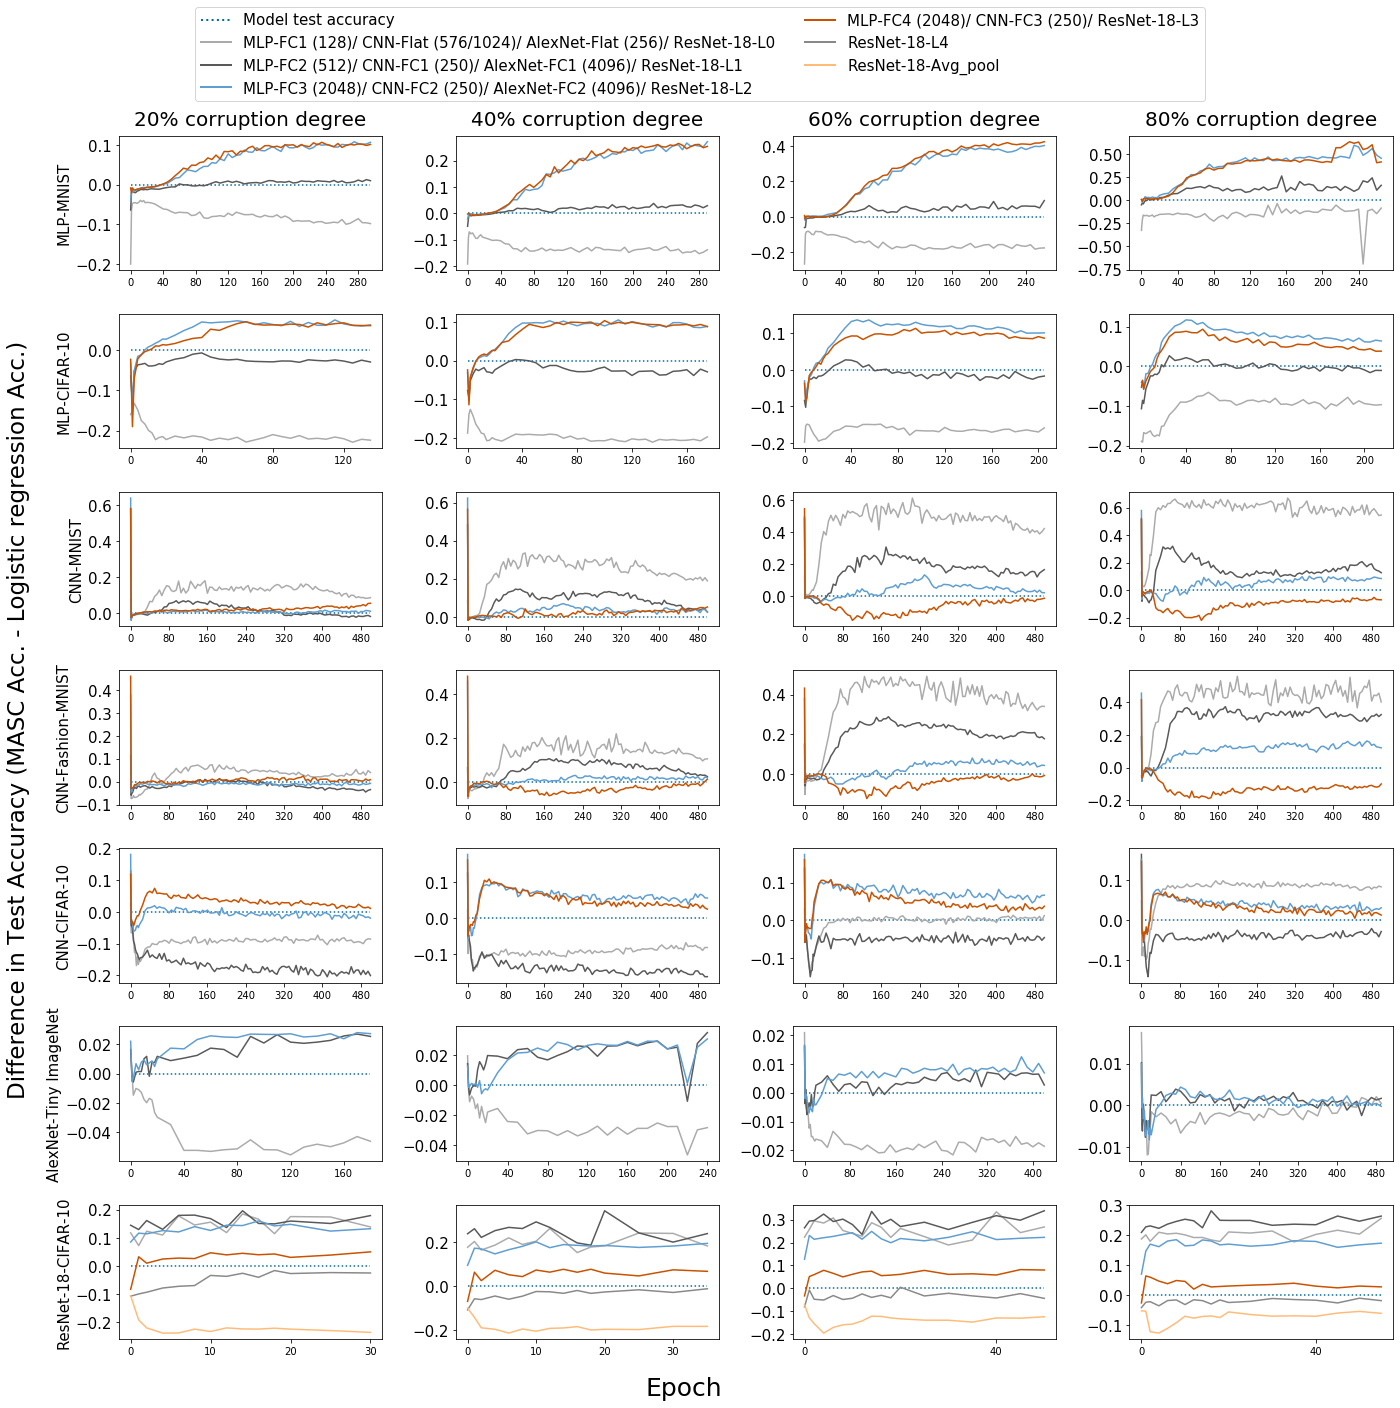

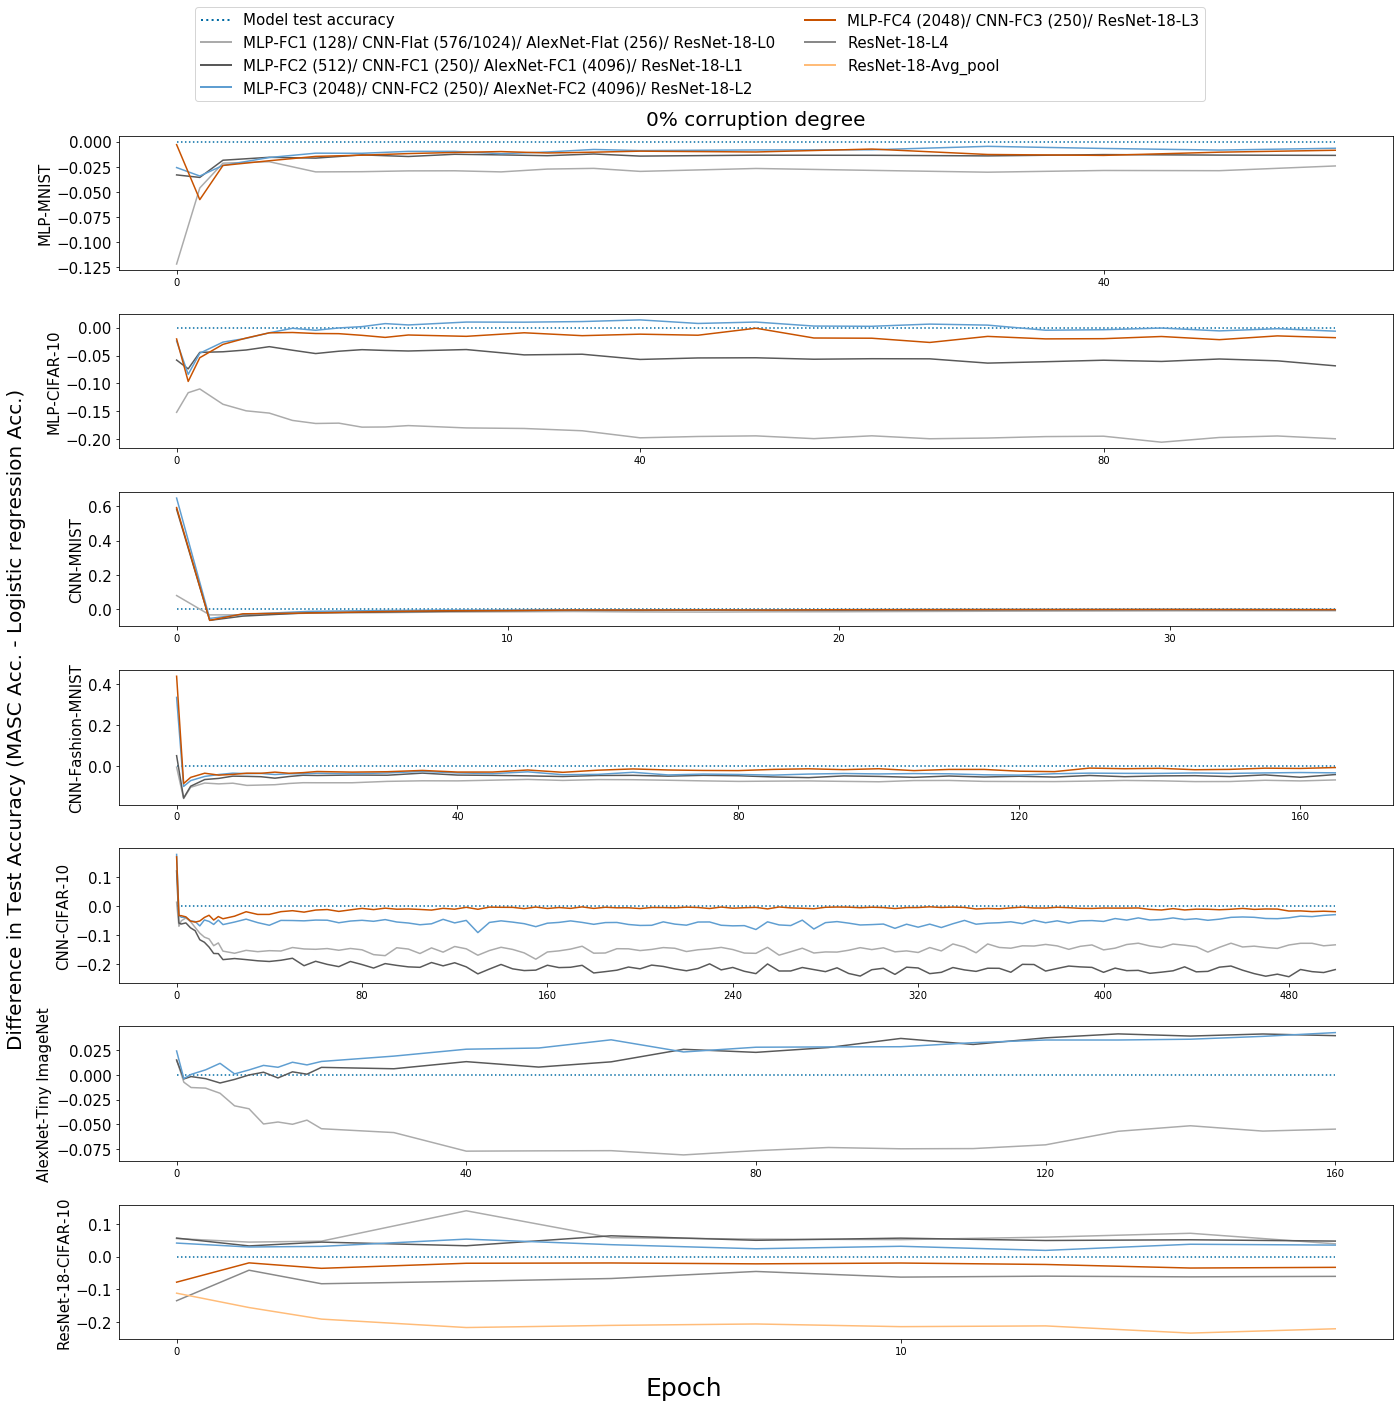

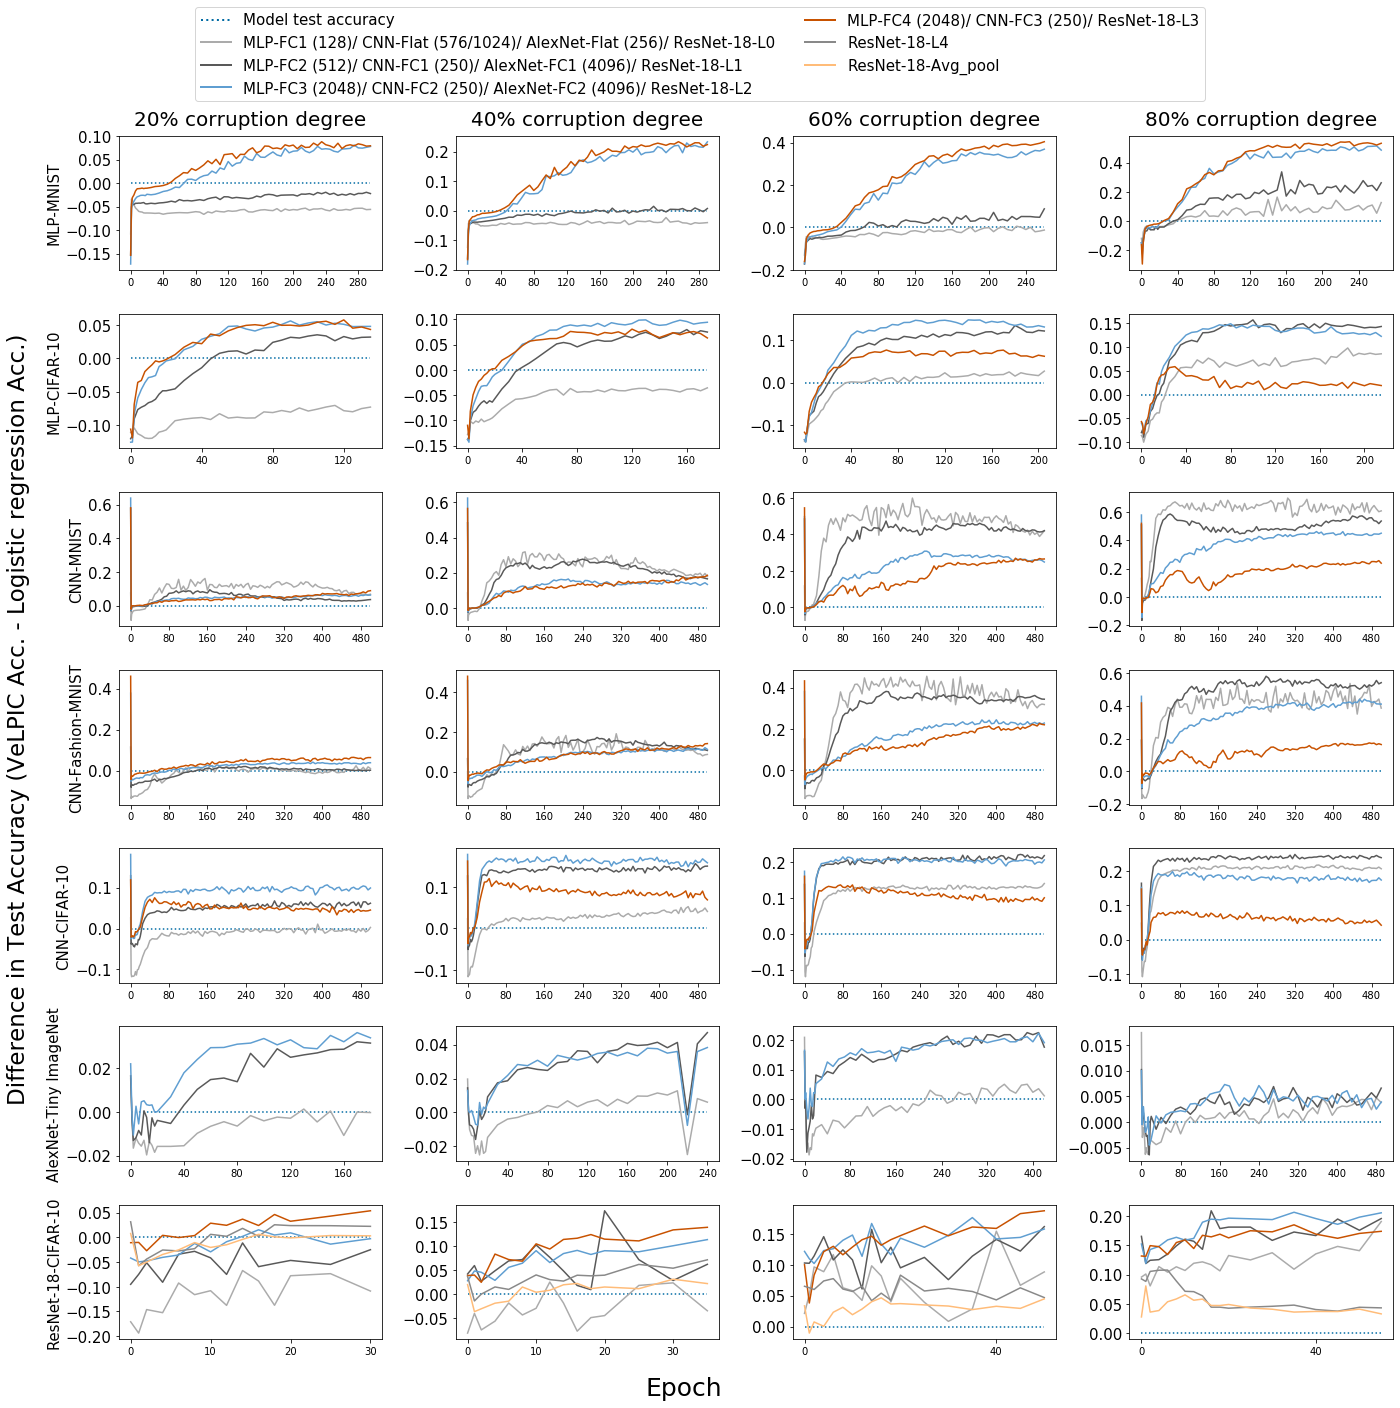

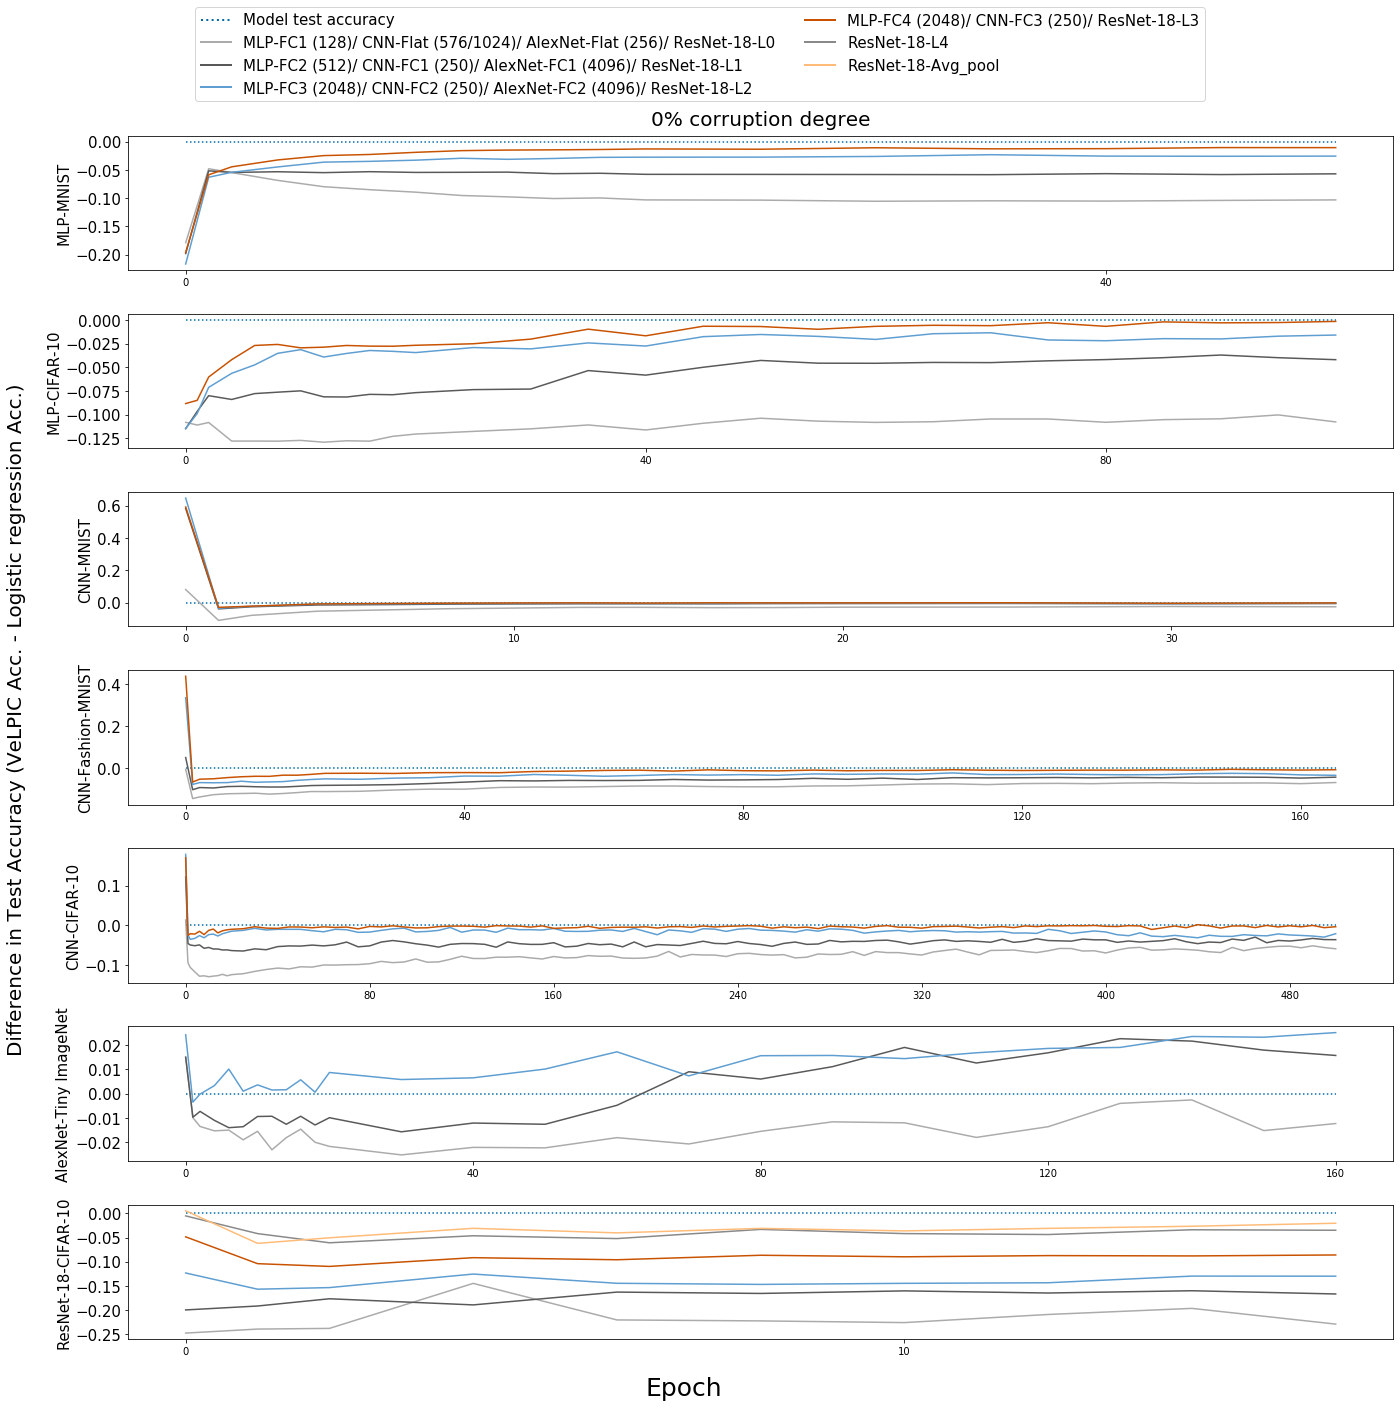

In [9]:
plo_diff=plot_DIFF()

resfoldername='TMLR_PAPER_PLOTS2'
plo_diff.plot_diff_log_reg(resfoldername,masc=True,corruptions=True)
plo_diff.plot_diff_log_reg(resfoldername,masc=True,corruptions=False)

plo_diff.plot_diff_log_reg(resfoldername,masc=False,corruptions=True)
plo_diff.plot_diff_log_reg(resfoldername,masc=False,corruptions=False)